In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [9]:
import os, cv2, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import HTML
import matplotlib.animation as animation
warnings.filterwarnings('ignore')

2026-03-06 17:42:10.328803: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772818930.354295   94150 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772818930.361960   94150 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772818930.382493   94150 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772818930.382527   94150 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772818930.382530   94150 computation_placer.cc:177] computation placer alr

In [10]:

# 2 GPU strategy
strategy = tf.distribute.MirroredStrategy()
print("GPUs:", strategy.num_replicas_in_sync)

BASE_PATH = "/kaggle/input/datasets/matthewjansen/ucf101-action-recognition"

# Chote values — memory safe

NUM_FRAMES        = 8      # 10 se 8
IMG_SIZE          = 64     # 112 se 64 ← sabse bada fark
BATCH_SIZE        = 32
EPOCHS            = 20
MAX_PER_CLASS_TRAIN = 30   # 80 se 30
MAX_PER_CLASS_VAL   = 10   # 20 se 10

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
GPUs: 2


I0000 00:00:1772818941.053666   94150 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772818941.059205   94150 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


CSV Structure
         clip_name                         clip_path  label
0  v_Swing_g05_c02  /train/Swing/v_Swing_g05_c02.avi  Swing
1  v_Swing_g21_c03  /train/Swing/v_Swing_g21_c03.avi  Swing
2  v_Swing_g07_c01  /train/Swing/v_Swing_g07_c01.avi  Swing
3  v_Swing_g24_c04  /train/Swing/v_Swing_g24_c04.avi  Swing
4  v_Swing_g20_c03  /train/Swing/v_Swing_g20_c03.avi  Swing

Columns: ['clip_name', 'clip_path', 'label']

Train: 10055 | Val: 1673 | Test: 1723
Total Classes: 101


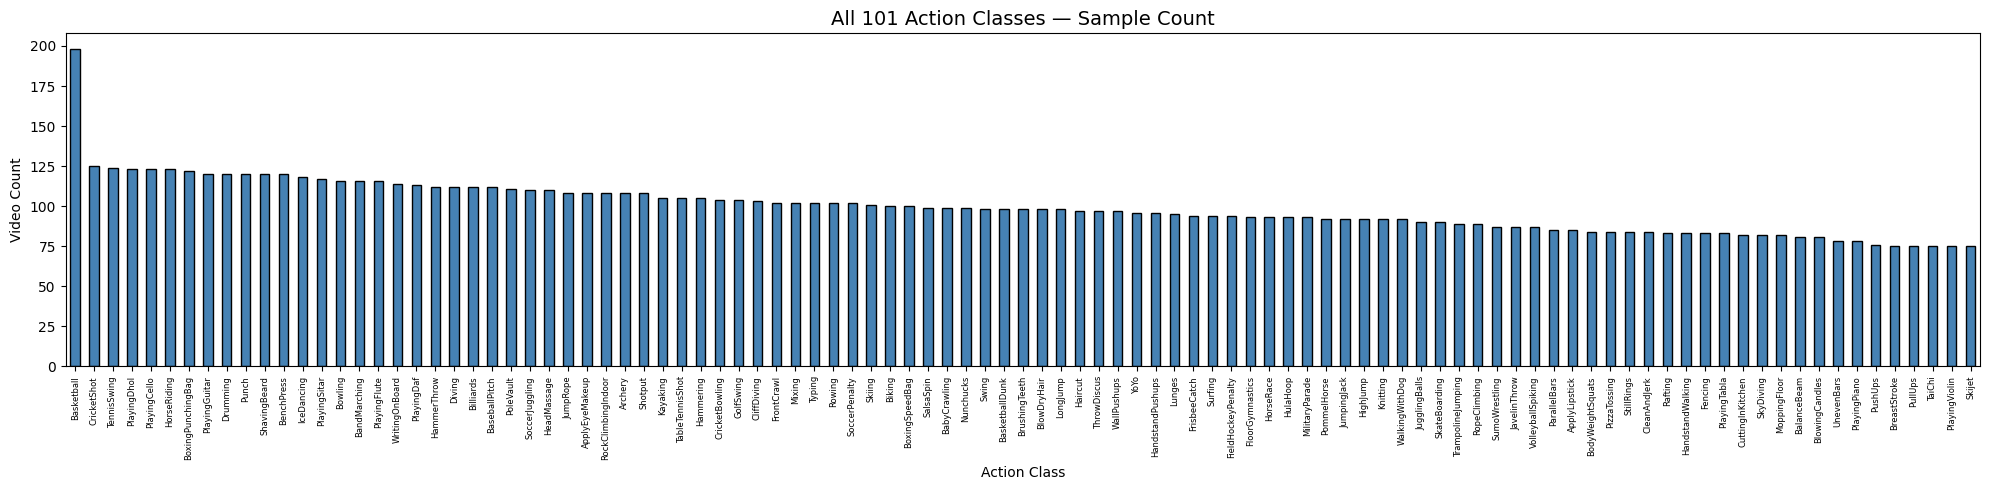

In [11]:
train_df = pd.read_csv(f"{BASE_PATH}/train.csv")
val_df   = pd.read_csv(f"{BASE_PATH}/val.csv")
test_df  = pd.read_csv(f"{BASE_PATH}/test.csv")

print("CSV Structure")
print(train_df.head())
print("\nColumns:", train_df.columns.tolist())
print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Total Classes: {train_df['label'].nunique()}")

# Class distribution

plt.figure(figsize=(20, 5))
train_df['label'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("All 101 Action Classes — Sample Count", fontsize=14)
plt.xlabel("Action Class")
plt.ylabel("Video Count")
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

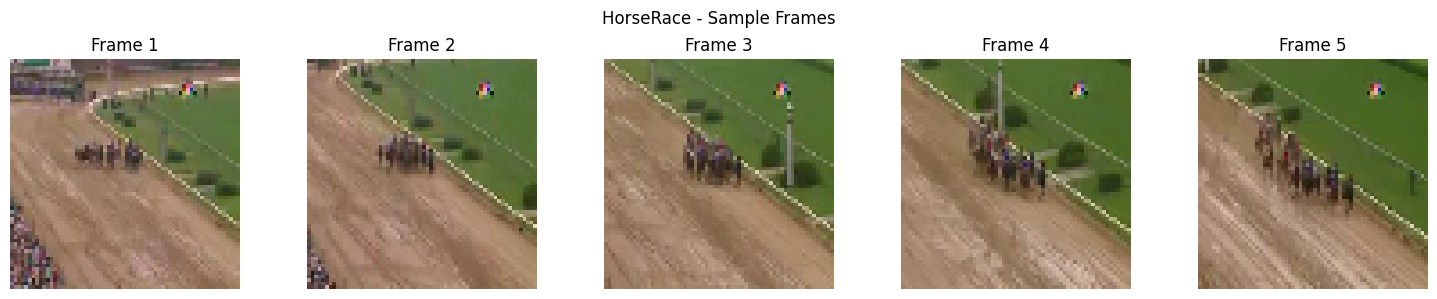

In [12]:
def extract_frames(video_path, num_frames=10):

    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total == 0:
        cap.release()
        return None
    
    indices = np.linspace(0, total - 1, num_frames, dtype=int)
    frames = []
    
    for i in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, (64, 64))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    
    cap.release()
    
    if len(frames) == num_frames:
        return np.array(frames)  # shape: (10, 64, 64, 3)
    return None

sample_video = f"{BASE_PATH}/val/HorseRace/v_HorseRace_g11_c01.avi"
frames = extract_frames(sample_video, num_frames=5)

if frames is not None:
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for i, ax in enumerate(axes):
        ax.imshow(frames[i])
        ax.axis('off')
        ax.set_title(f"Frame {i+1}")
    plt.suptitle("HorseRace - Sample Frames")
    plt.tight_layout()
    plt.show()

In [13]:
def extract_frames(video_path, num_frames=8, img_size=64):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None
    
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < num_frames:
        cap.release()
        return None
    
    indices = np.linspace(0, total - 1, num_frames, dtype=int)
    frames  = []
    
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, (img_size, img_size))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    
    cap.release()
    
    if len(frames) == num_frames:
        return np.array(frames, dtype=np.float32) / 255.0
    return None

In [14]:
def get_full_path(row, base_path):
    for col in ['clip_path', 'video_path', 'path', 'filename', 'file']:
        if col in row.index:
            p = os.path.join(base_path, str(row[col]).lstrip('/'))
            if os.path.exists(p):
                return p
    
    first_val = str(row.iloc[0]).lstrip('/')
    p = os.path.join(base_path, first_val)
    if os.path.exists(p):
        return p
    return None

# Test
print(get_full_path(train_df.iloc[0], BASE_PATH))

/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/train/Swing/v_Swing_g05_c02.avi


In [15]:
class VideoDataGenerator(tf.keras.utils.Sequence):

    def __init__(self, df, base_path, label_encoder, 
                 num_frames=8, img_size=64, 
                 batch_size=32, max_per_class=30, shuffle=True):
        
        self.base_path     = base_path
        self.le            = label_encoder
        self.num_frames    = num_frames
        self.img_size      = img_size
        self.batch_size    = batch_size
        self.shuffle       = shuffle
        
        subset = df.groupby('label').head(max_per_class).reset_index(drop=True)
        
        # Valid paths only 
        print("Validating video paths...")
        valid_rows = []
        for _, row in subset.iterrows():
            p = get_full_path(row, base_path)
            if p and os.path.exists(p):
                valid_rows.append({'path': p, 'label': row['label']})
        
        self.data = pd.DataFrame(valid_rows)
        print(f" Valid videos: {len(self.data)}")
        
        if shuffle:
            self.data = self.data.sample(frac=1).reset_index(drop=True)
    
    def __len__(self):
        return int(np.ceil(len(self.data) / self.batch_size))
    
    def __getitem__(self, idx):
        batch = self.data.iloc[idx * self.batch_size : (idx+1) * self.batch_size]
        
        X, y = [], []
        for _, row in batch.iterrows():
            frames = extract_frames(row['path'], self.num_frames, self.img_size)
            if frames is not None:
                X.append(frames)
                y.append(self.le.transform([row['label']])[0])
        
        if len(X) == 0:
            # Empty batch edge case
            X = np.zeros((1, self.num_frames, self.img_size, self.img_size, 3))
            y = np.zeros(1)
        
        return np.array(X), np.array(y)
    
    def on_epoch_end(self):
        if self.shuffle:
            self.data = self.data.sample(frac=1).reset_index(drop=True)


# Label Encoder 

le = LabelEncoder()
le.fit(train_df['label'].unique())
NUM_CLASSES = len(le.classes_)
print(f"Total Classes: {NUM_CLASSES}")

# Generators — RAM safe 

train_gen = VideoDataGenerator(train_df, BASE_PATH, le,
                                num_frames=NUM_FRAMES,
                                img_size=IMG_SIZE,
                                batch_size=BATCH_SIZE,
                                max_per_class=MAX_PER_CLASS_TRAIN)

val_gen = VideoDataGenerator(val_df, BASE_PATH, le,
                              num_frames=NUM_FRAMES,
                              img_size=IMG_SIZE,
                              batch_size=BATCH_SIZE,
                              max_per_class=MAX_PER_CLASS_VAL,
                              shuffle=False)

print(f"\n Train batches: {len(train_gen)}")
print(f" Val batches:   {len(val_gen)}")

# Memory check

sample_X, sample_y = train_gen[0]
print(f"\n Sample batch — X: {sample_X.shape} | y: {sample_y.shape}")

Total Classes: 101
Validating video paths...
 Valid videos: 3030
Validating video paths...
 Valid videos: 1010

 Train batches: 95
 Val batches:   32

 Sample batch — X: (32, 8, 64, 64, 3) | y: (32,)


In [16]:
with strategy.scope():
    mobilenet = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        pooling='avg'
    )
    mobilenet.trainable = False
    
    frame_input = layers.Input(shape=(NUM_FRAMES, IMG_SIZE, IMG_SIZE, 3))
    
    x = layers.TimeDistributed(mobilenet)(frame_input)
    x = layers.TimeDistributed(layers.Dense(128, activation='relu'))(x)
    x = layers.TimeDistributed(layers.Dropout(0.3))(x)
    
    x = layers.LSTM(128, return_sequences=False)(x)
    x = layers.Dropout(0.4)(x)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    output = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=frame_input, outputs=output)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8, 64, 64, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 8, 1280)        │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 8, 128)         │       163,968 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 8, 128)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 101)            │        25,957 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,613,541 (9.97 MB)

 Trainable params: 355,045 (1.35 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [17]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("Training start!")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Training start!
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO

I0000 00:00:1772819083.863905   94222 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772819083.936282   94224 cuda_dnn.cc:529] Loaded cuDNN version 91002


95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0152 - loss: 5.1709INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_accuracy improved from -inf to 0.11409, saving model to best_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 404s 4s/step - accuracy: 0.0153 - loss: 5.1684 - val_accuracy: 0.1141 - val_loss: 4.3329 - learning_rate: 0.0010
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0744 - loss: 4.1993
Epoch 2: val_accuracy improved from 0.11409 to 0.19940, saving model to best_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 322s 3s/step - accuracy: 0.0746 - loss: 4.1978 - val_accuracy: 0.1994 - val_loss: 3.7226 - learning_rate: 0.0010
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1753 - loss: 3.4278
Epoch 3: val_accuracy impro


ACTION RECOGNITION RESULT
  1. Biking                        82.7%  ████████████████████ <-- Predicted
  2. HorseRace                     16.7%  ████ 
  3. ThrowDiscus                    0.2%   
  4. Lunges                         0.2%   
  5. HorseRiding                    0.1%   


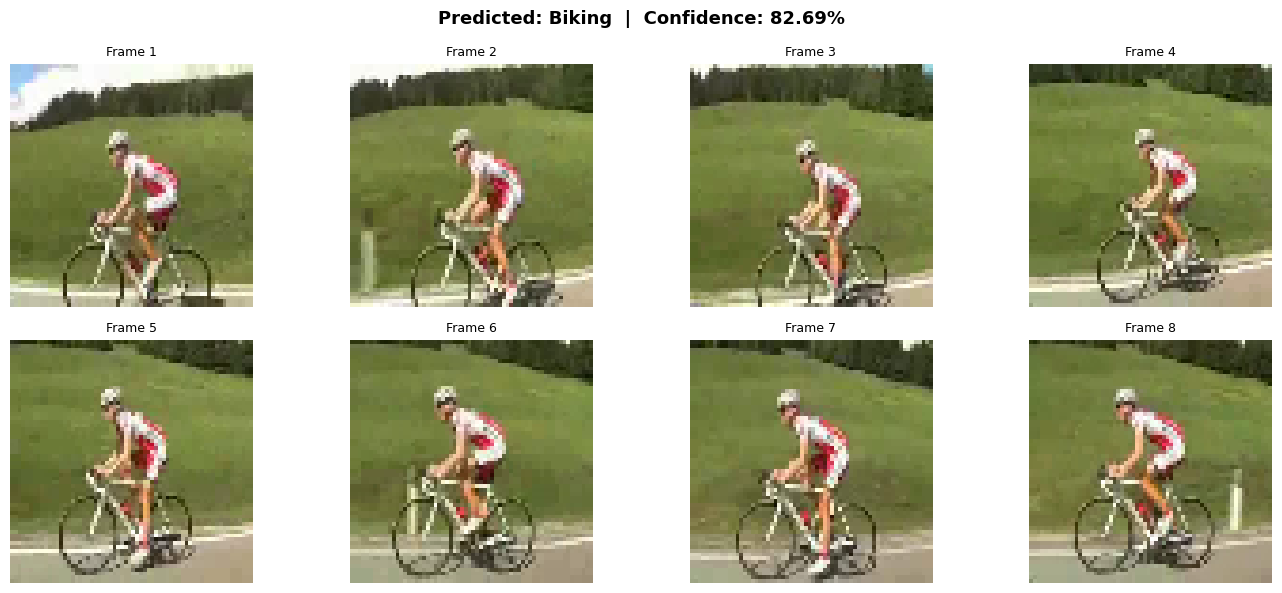

In [22]:
def predict_action(video_path, model, label_encoder):
    frames = extract_frames(video_path, NUM_FRAMES, IMG_SIZE)
    
    if frames is None:
        print("Video could not be loaded.")
        return
    
    inp = np.expand_dims(frames, axis=0)  # shape: (1, 8, 64, 64, 3)
    
    # model.predict() MirroredStrategy ke saath crash karta hai single sample pe
    # Direct call use karo instead
    pred = model(inp, training=False).numpy()[0]
    
    top5 = np.argsort(pred)[::-1][:5]
    
    print("\n" + "=" * 45)
    print("ACTION RECOGNITION RESULT")
    print("=" * 45)
    
    for rank, idx in enumerate(top5):
        bar    = "█" * int(pred[idx] * 25)
        marker = "<-- Predicted" if rank == 0 else ""
        print(f"  {rank+1}. {label_encoder.classes_[idx]:<28} {pred[idx]*100:5.1f}%  {bar} {marker}")
    
    print("=" * 45)
    
    # Display frames
    fig, axes = plt.subplots(2, 4, figsize=(14, 6))
    axes = axes.flatten()
    
    for i in range(min(NUM_FRAMES, 8)):
        axes[i].imshow(frames[i])
        axes[i].axis('off')
        axes[i].set_title(f"Frame {i+1}", fontsize=9)
    
    predicted_label = label_encoder.classes_[np.argsort(pred)[::-1][0]]
    confidence      = pred[np.argsort(pred)[::-1][0]] * 100
    
    plt.suptitle(
        f"Predicted: {predicted_label}  |  Confidence: {confidence:.2f}%",
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


# Run
predict_action(
    f"{BASE_PATH}/val/Biking/v_Biking_g17_c02.avi",
    model, le
)

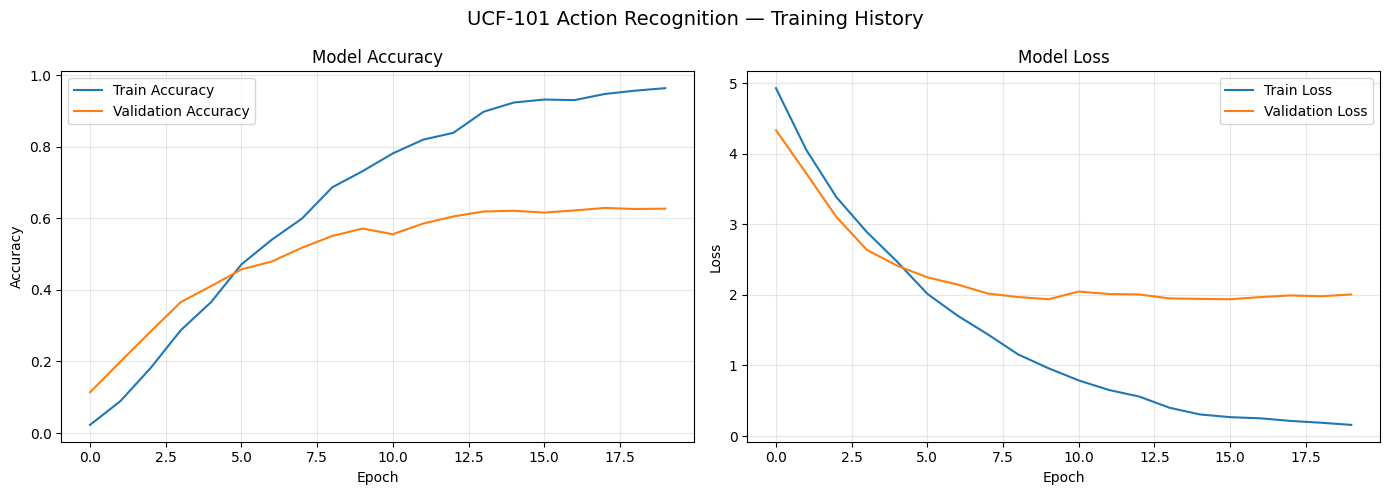

In [23]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle('UCF-101 Action Recognition — Training History', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_training_history(history)


ACTION RECOGNITION RESULT
  1. HorseRace                     49.6%  ████████████ <-- Predicted
  2. HorseRiding                   13.9%  ███ 
  3. Lunges                        13.3%  ███ 
  4. JavelinThrow                   8.9%  ██ 
  5. CricketShot                    3.7%   


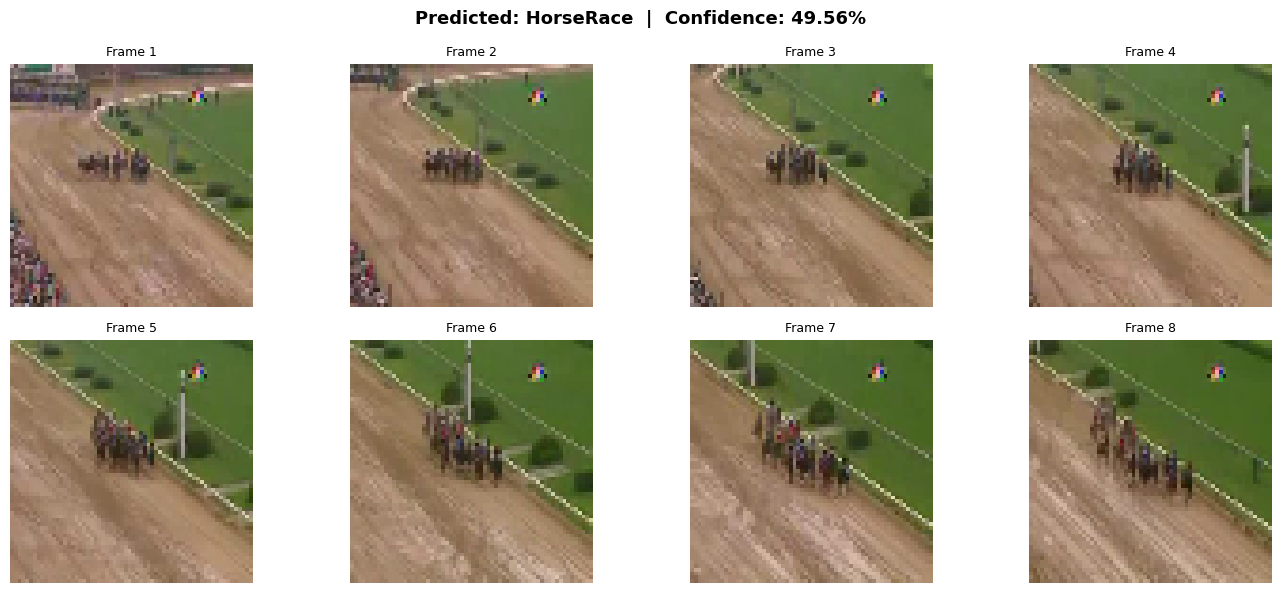


ACTION RECOGNITION RESULT
  1. ThrowDiscus                   38.2%  █████████ <-- Predicted
  2. RopeClimbing                  31.4%  ███████ 
  3. Mixing                        16.1%  ████ 
  4. HammerThrow                    2.5%   
  5. Skiing                         1.6%   


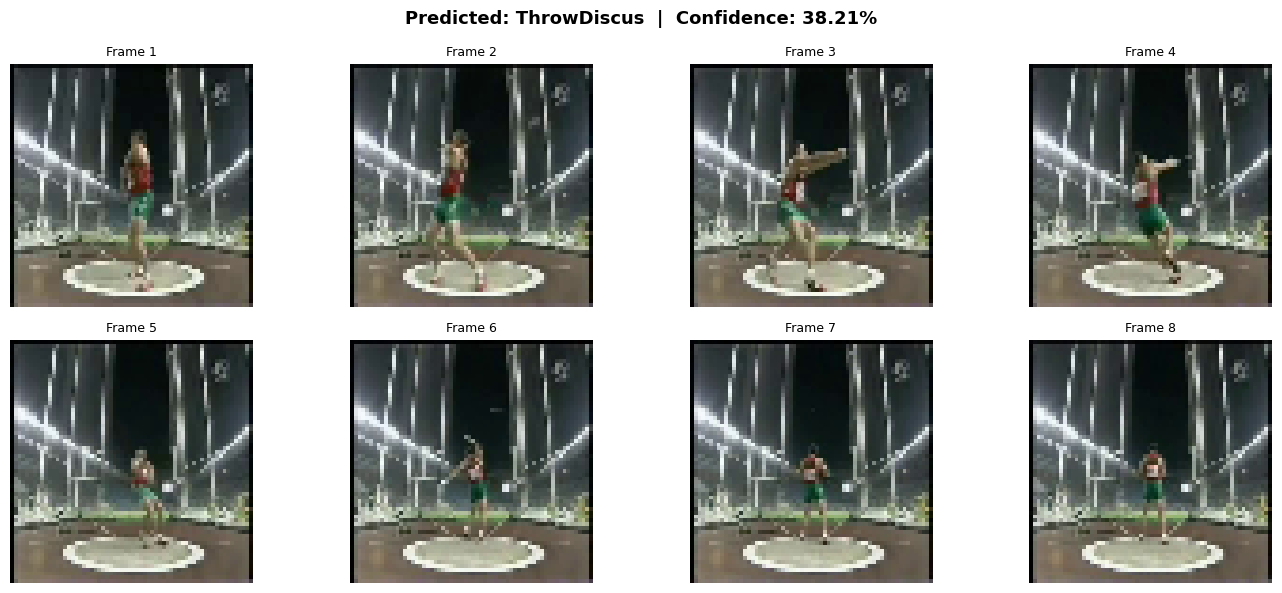


ACTION RECOGNITION RESULT
  1. ApplyLipstick                 93.5%  ███████████████████████ <-- Predicted
  2. BrushingTeeth                  2.8%   
  3. BlowDryHair                    1.8%   
  4. ApplyEyeMakeup                 1.4%   
  5. BoxingPunchingBag              0.3%   


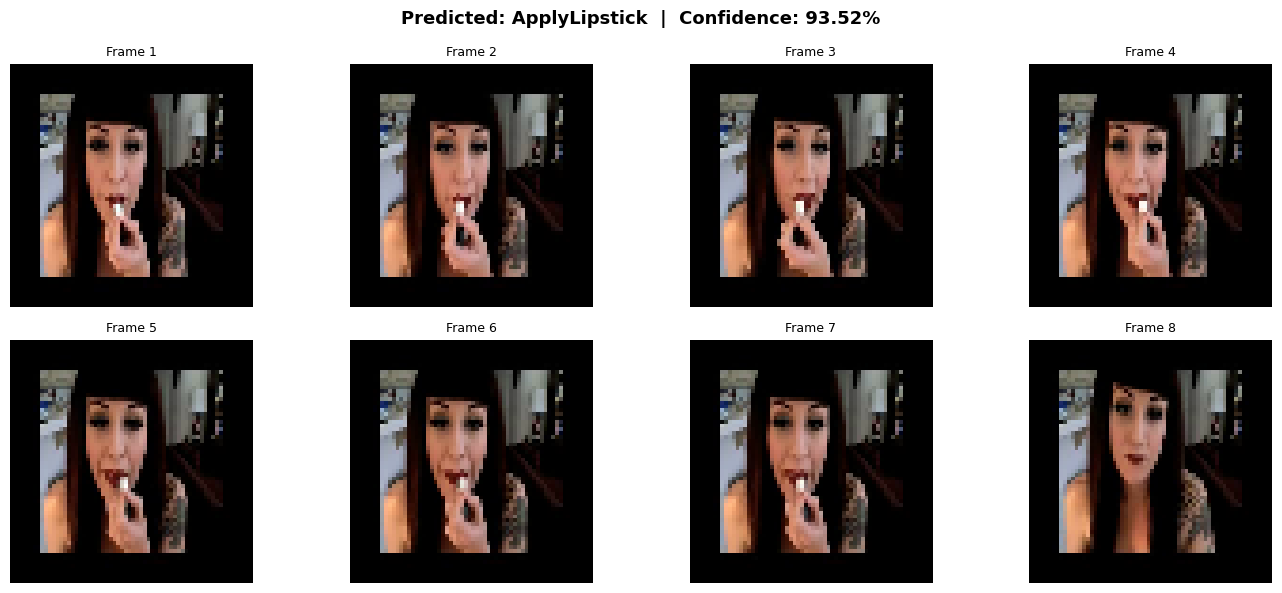


ACTION RECOGNITION RESULT
  1. VolleyballSpiking             81.3%  ████████████████████ <-- Predicted
  2. PizzaTossing                   8.6%  ██ 
  3. Diving                         4.4%  █ 
  4. Punch                          3.0%   
  5. BoxingSpeedBag                 1.4%   


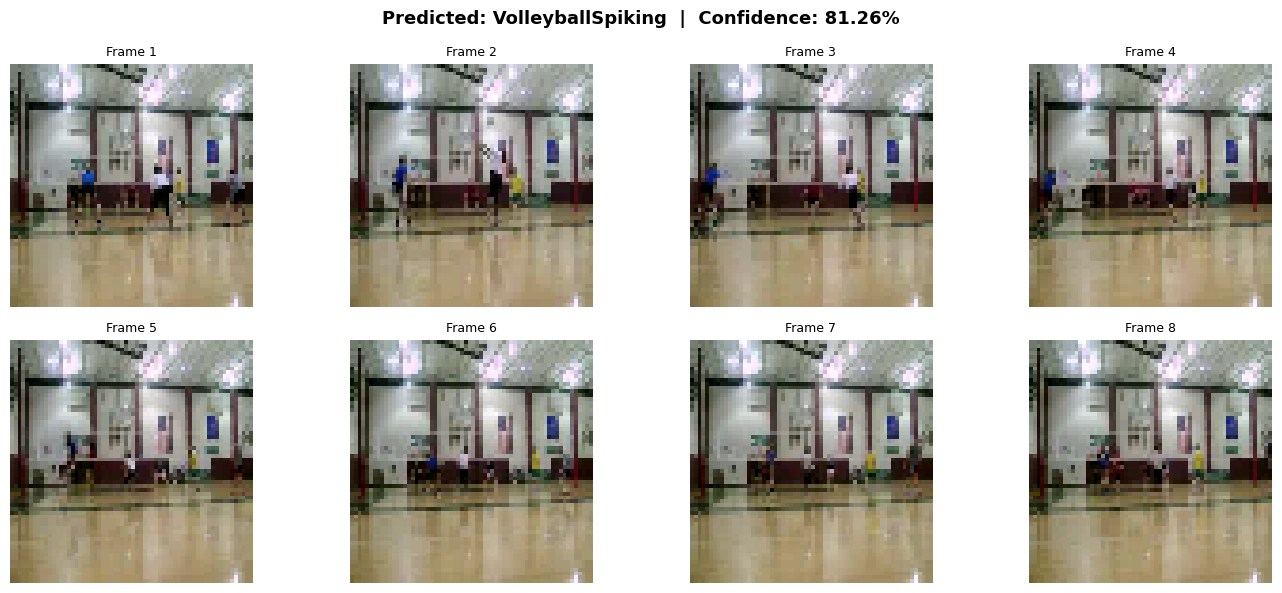

In [24]:
test_videos = [
    f"{BASE_PATH}/val/HorseRace/v_HorseRace_g11_c01.avi",
    f"{BASE_PATH}/val/HammerThrow/v_HammerThrow_g18_c03.avi",
    f"{BASE_PATH}/val/ApplyLipstick/v_ApplyLipstick_g09_c04.avi",
    f"{BASE_PATH}/val/VolleyballSpiking/v_VolleyballSpiking_g22_c04.avi",
]

for video in test_videos:
    predict_action(video, model, le)